# Food Delivery Marketplace Analytics
## 01 — Exploratory Data Analysis & Marketplace Overview

Comprehensive overview of marketplace health, customer behavior, and operational metrics.

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

# Add project root to path
BASE_DIR = Path().resolve().parent
sys.path.insert(0, str(BASE_DIR))

from src.db_connect import get_engine, execute_query

# Configure visualization defaults
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("[SUCCESS] Environment initialized successfully")

✅ Environment initialized successfully


## 1. Database Connection & Data Loading

Connect to the marketplace database and load key fact tables.

In [ ]:
# Connect to database
engine, dialect = get_engine()
print(f"[SUCCESS] Connected to {dialect.upper()} database")

# Load core tables
with engine.connect() as conn:
    df_orders = pd.read_sql("SELECT * FROM fact_orders", conn)
    df_order_items = pd.read_sql("SELECT * FROM fact_order_items", conn)
    df_customers = pd.read_sql("SELECT * FROM dim_customers", conn)
    df_products = pd.read_sql("SELECT * FROM dim_products", conn)
    df_sellers = pd.read_sql("SELECT * FROM dim_sellers", conn)
    df_reviews = pd.read_sql("SELECT * FROM fact_order_reviews", conn)

print(f"Orders:       {len(df_orders):>8,} records")
print(f"Order Items:  {len(df_order_items):>8,} records")
print(f"Customers:    {len(df_customers):>8,} records")
print(f"Products:     {len(df_products):>8,} records")
print(f"Sellers:      {len(df_sellers):>8,} records")
print(f"Reviews:      {len(df_reviews):>8,} records")

✅ Connected to SQLITE database
Orders:         53,500 records
Order Items:    61,541 records
Customers:      53,500 records
Products:        4,000 records
Sellers:         1,200 records
Reviews:        50,892 records


## 2. Dataset Overview & Quality Checks

Core statistics and data quality validation.

In [3]:
# Orders data type validation
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

print("Orders Data Summary:")
print(f"  • Date range: {df_orders['order_purchase_timestamp'].min().date()} to {df_orders['order_purchase_timestamp'].max().date()}")
print(f"  • Total orders: {len(df_orders):,}")
print(f"  • Delivered: {(df_orders['order_status'] == 'delivered').sum():,} ({(df_orders['order_status'] == 'delivered').sum() / len(df_orders) * 100:.1f}%)")
print(f"  • Canceled: {(df_orders['order_status'] == 'canceled').sum():,} ({(df_orders['order_status'] == 'canceled').sum() / len(df_orders) * 100:.1f}%)")
print(f"  • Shipped: {(df_orders['order_status'] == 'shipped').sum():,} ({(df_orders['order_status'] == 'shipped').sum() / len(df_orders) * 100:.1f}%)")
print()

# Customer statistics
unique_customers = df_orders['customer_id'].nunique()
unique_buyers = df_customers['customer_unique_id'].nunique()
print(f"Customer Statistics:")
print(f"  • Unique customer records: {unique_customers:,}")
print(f"  • Unique buyers (repeat ID): {unique_buyers:,}")
print(f"  • Orders per buyer: {len(df_orders) / unique_buyers:.2f}")

Orders Data Summary:
  • Date range: 2017-01-01 to 2018-06-30
  • Total orders: 53,500
  • Delivered: 51,936 (97.1%)
  • Canceled: 972 (1.8%)
  • Shipped: 592 (1.1%)

Customer Statistics:
  • Unique customer records: 53,500
  • Unique buyers (repeat ID): 31,200
  • Orders per buyer: 1.71


## 3. Monthly Marketplace Metrics

Track key KPIs across time periods.

In [4]:
# Aggregate order items to order level
order_gmv = df_order_items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()
order_gmv['order_gmv'] = order_gmv['price'] + order_gmv['freight_value']

# Merge with orders
df_orders_enriched = df_orders.merge(order_gmv[['order_id', 'order_gmv']], on='order_id', how='left')

# Monthly aggregation (delivered orders only)
df_orders_enriched['order_month'] = df_orders_enriched['order_purchase_timestamp'].dt.strftime('%Y-%m')
delivered = df_orders_enriched[df_orders_enriched['order_status'] == 'delivered'].copy()

monthly_kpis = delivered.groupby('order_month').agg({
    'order_id': 'count',
    'customer_id': 'nunique',
    'order_gmv': ['sum', 'mean']
}).round(2)

monthly_kpis.columns = ['orders', 'customers', 'total_gmv', 'aov']
monthly_kpis['revenue_per_customer'] = (monthly_kpis['total_gmv'] / monthly_kpis['customers']).round(2)
monthly_kpis = monthly_kpis.reset_index()

print("Monthly KPIs (Delivered Orders Only):")
print(monthly_kpis.to_string(index=False))

Monthly KPIs (Delivered Orders Only):
order_month  orders  customers  total_gmv    aov  revenue_per_customer
    2017-01     784        784  135230.09 172.49                172.49
    2017-02    1073       1073  184755.92 172.19                172.19
    2017-03    1467       1467  252436.55 172.08                172.08
    2017-04    1561       1561  268980.11 172.31                172.31
    2017-05    1950       1950  327850.49 168.13                168.13
    2017-06    2038       2038  353656.33 173.53                173.53
    2017-07    2326       2326  400458.96 172.17                172.17
    2017-08    2631       2631  448358.63 170.41                170.41
    2017-09    2698       2698  457953.51 169.74                169.74
    2017-10    3009       3009  514051.75 170.84                170.84
    2017-11    4070       4070  692292.91 170.10                170.10
    2017-12    3403       3403  575927.64 169.24                169.24
    2018-01    3959       3959  676701.

## 4. Visualization: Monthly Trends

Plot key metrics over time.

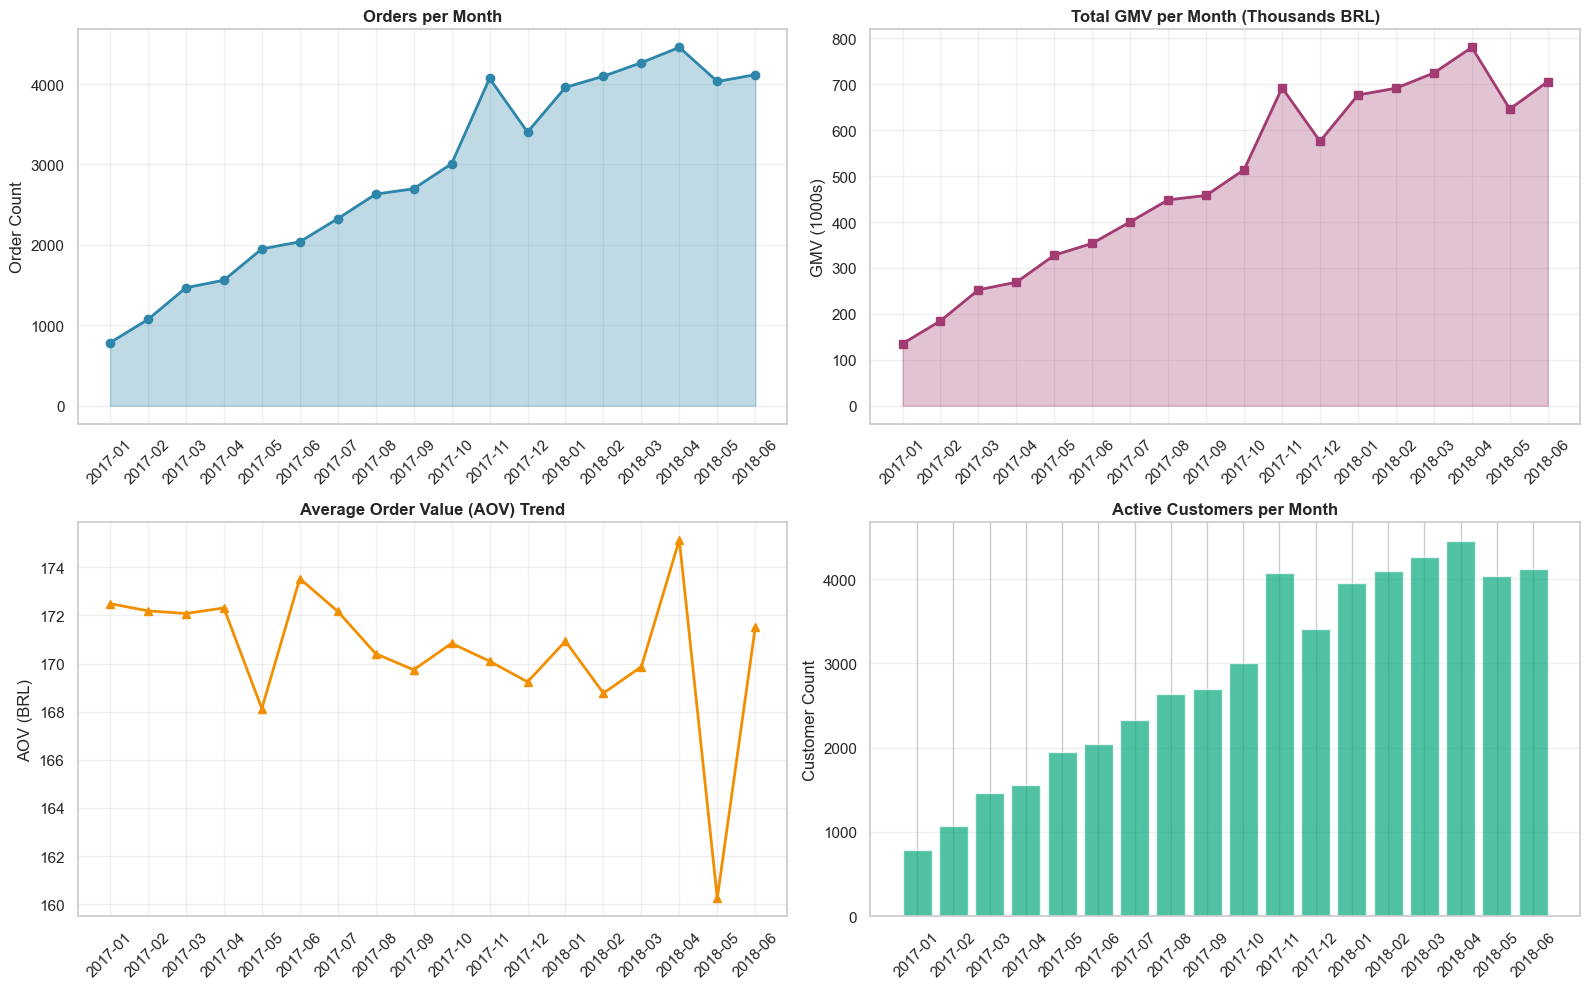

✅ Figure saved to reports/01_monthly_trends.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Orders trend
ax = axes[0, 0]
ax.plot(monthly_kpis['order_month'], monthly_kpis['orders'], marker='o', linewidth=2, markersize=6, color='#2E86AB')
ax.fill_between(range(len(monthly_kpis)), monthly_kpis['orders'], alpha=0.3, color='#2E86AB')
ax.set_title('Orders per Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Order Count')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# GMV trend
ax = axes[0, 1]
ax.plot(monthly_kpis['order_month'], monthly_kpis['total_gmv'] / 1000, marker='s', linewidth=2, markersize=6, color='#A23B72')
ax.fill_between(range(len(monthly_kpis)), monthly_kpis['total_gmv'] / 1000, alpha=0.3, color='#A23B72')
ax.set_title('Total GMV per Month (Thousands BRL)', fontsize=12, fontweight='bold')
ax.set_ylabel('GMV (1000s)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# AOV trend
ax = axes[1, 0]
ax.plot(monthly_kpis['order_month'], monthly_kpis['aov'], marker='^', linewidth=2, markersize=6, color='#F18F01')
ax.set_title('Average Order Value (AOV) Trend', fontsize=12, fontweight='bold')
ax.set_ylabel('AOV (BRL)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Active Customers
ax = axes[1, 1]
ax.bar(monthly_kpis['order_month'], monthly_kpis['customers'], color='#06A77D', alpha=0.7)
ax.set_title('Active Customers per Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Customer Count')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / '01_monthly_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("[SUCCESS] Figure saved to reports/01_monthly_trends.png")

## 5. Geographic Analysis

Customer and order distribution by state.

Top 10 States by Order Volume:
customer_state  orders  customers  total_gmv    aov
            SP   21976      21976 3742104.39 170.28
            RJ    6527       6527 1102624.79 168.93
            MG    6451       6451 1104092.38 171.15
            RS    3089       3089  520850.07 168.61
            PR    2594       2594  451280.30 173.97
            BA    2112       2112  354139.88 167.68
            SC    2046       2046  344825.31 168.54
            DF    1561       1561  265099.91 169.83
            ES    1087       1087  184969.52 170.17
            CE    1038       1038  177496.43 171.00


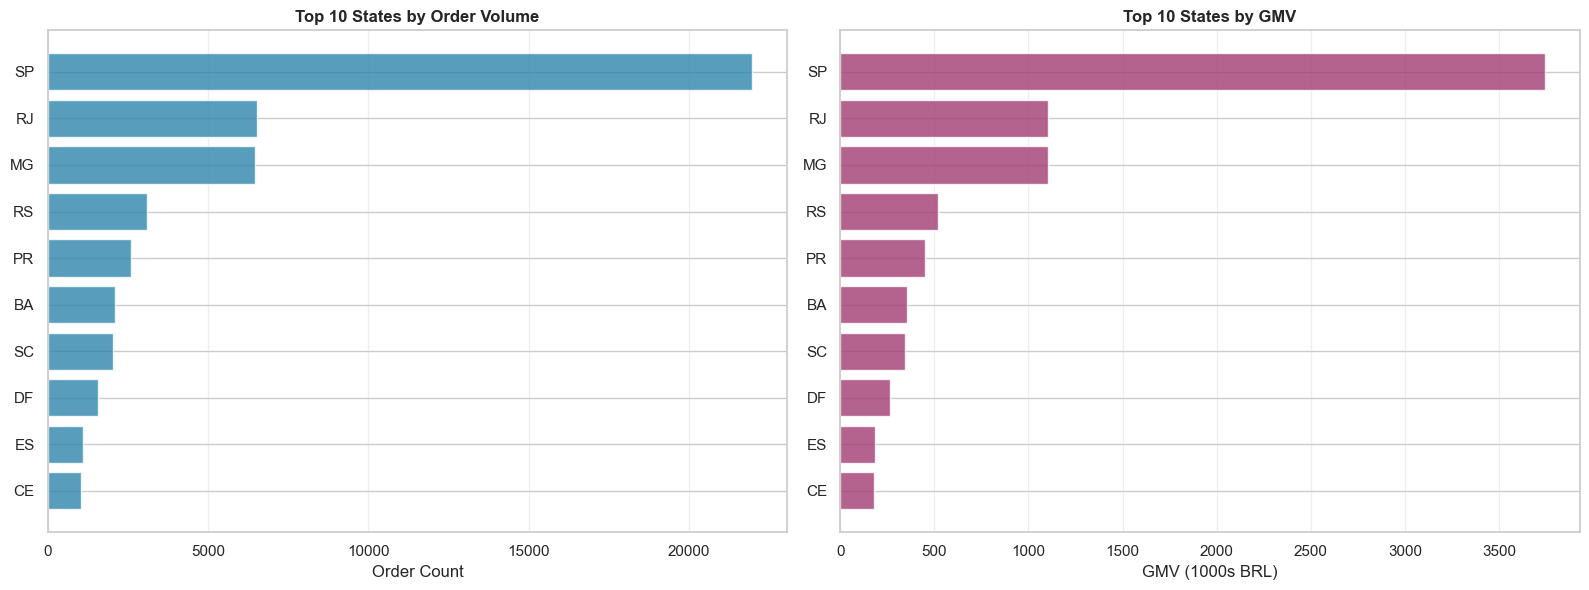


✅ Figure saved to reports/02_geographic_analysis.png


In [ ]:
# Merge customer state info
df_geo = df_orders_enriched.merge(df_customers[['customer_id', 'customer_state']], on='customer_id', how='left')
delivered_geo = df_geo[df_geo['order_status'] == 'delivered'].copy()

# State aggregation
state_metrics = delivered_geo.groupby('customer_state').agg({
    'order_id': 'count',
    'customer_id': 'nunique',
    'order_gmv': ['sum', 'mean']
}).round(2)

state_metrics.columns = ['orders', 'customers', 'total_gmv', 'aov']
state_metrics = state_metrics.sort_values('orders', ascending=False).reset_index()

print("Top 10 States by Order Volume:")
print(state_metrics.head(10).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
top_states = state_metrics.head(10)
ax.barh(top_states['customer_state'], top_states['orders'], color='#2E86AB', alpha=0.8)
ax.set_xlabel('Order Count')
ax.set_title('Top 10 States by Order Volume', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1]
ax.barh(top_states['customer_state'], top_states['total_gmv'] / 1000, color='#A23B72', alpha=0.8)
ax.set_xlabel('GMV (1000s BRL)')
ax.set_title('Top 10 States by GMV', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / '02_geographic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[SUCCESS] Figure saved to reports/02_geographic_analysis.png")

## 6. Product Category Analysis

Performance metrics by product category.

In [ ]:
# Merge product data
df_items_cat = df_order_items.merge(df_products[['product_id', 'category_name_english']], on='product_id', how='left')
df_items_cat = df_items_cat.merge(df_orders[['order_id', 'order_status']], on='order_id', how='left')
delivered_items = df_items_cat[df_items_cat['order_status'] == 'delivered'].copy()

# Category aggregation
category_metrics = delivered_items.groupby('category_name_english').agg({
    'order_id': 'count',
    'price': 'mean',
    'freight_value': 'mean'
}).round(2)

category_metrics['gmv_per_item'] = (category_metrics['price'] + category_metrics['freight_value']).round(2)
category_metrics = category_metrics.sort_values('order_id', ascending=False).reset_index()
category_metrics.columns = ['category', 'items_sold', 'avg_price', 'avg_freight', 'gmv_per_item']

print("\nTop 15 Categories by Item Volume:")
print(category_metrics.head(15).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))

top_cats = category_metrics.head(12)
x_pos = np.arange(len(top_cats))
ax.bar(x_pos, top_cats['items_sold'], color='#2E86AB', alpha=0.7, label='Items Sold')
ax2 = ax.twinx()
ax2.plot(x_pos, top_cats['gmv_per_item'], color='#A23B72', marker='o', linewidth=2, markersize=8, label='GMV per Item')

ax.set_xticks(x_pos)
ax.set_xticklabels(top_cats['category'], rotation=45, ha='right')
ax.set_ylabel('Items Sold', color='#2E86AB')
ax2.set_ylabel('GMV per Item (BRL)', color='#A23B72')
ax.set_title('Top 12 Product Categories: Volume vs Value', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / '03_category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[SUCCESS] Figure saved to reports/03_category_analysis.png")

## 7. Customer Review Sentiment Analysis

Order quality and customer satisfaction metrics.

In [ ]:
# Review statistics
print("Review Score Distribution:")
review_dist = df_reviews['review_score'].value_counts().sort_index()
print(review_dist)
print(f"\nAverage Review Score: {df_reviews['review_score'].mean():.2f} / 5.0")
print(f"Total Reviews: {len(df_reviews):,}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution bar chart
ax = axes[0]
colors = ['#E63946', '#F77F00', '#FCBF49', '#D3E34F', '#06A77D']
ax.bar(review_dist.index, review_dist.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Review Score')
ax.set_ylabel('Count')
ax.set_title('Review Score Distribution', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.grid(True, alpha=0.3, axis='y')

# Pie chart
ax = axes[1]
score_labels = ['1-Star (Bad)', '2-Star (Poor)', '3-Star (OK)', '4-Star (Good)', '5-Star (Excellent)']
ax.pie(review_dist.values, labels=score_labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Review Score Breakdown', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / '04_review_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[SUCCESS] Figure saved to reports/04_review_analysis.png")

## 8. Delivery Performance Metrics

On-time delivery rates and fulfillment analysis.

Delivery Metrics (Delivered Orders):
  • On-time delivery rate: 95.2%
  • Average days to deliver: 10.5 days
  • Median days to deliver: 10 days
  • Min/Max: 3 / 18 days


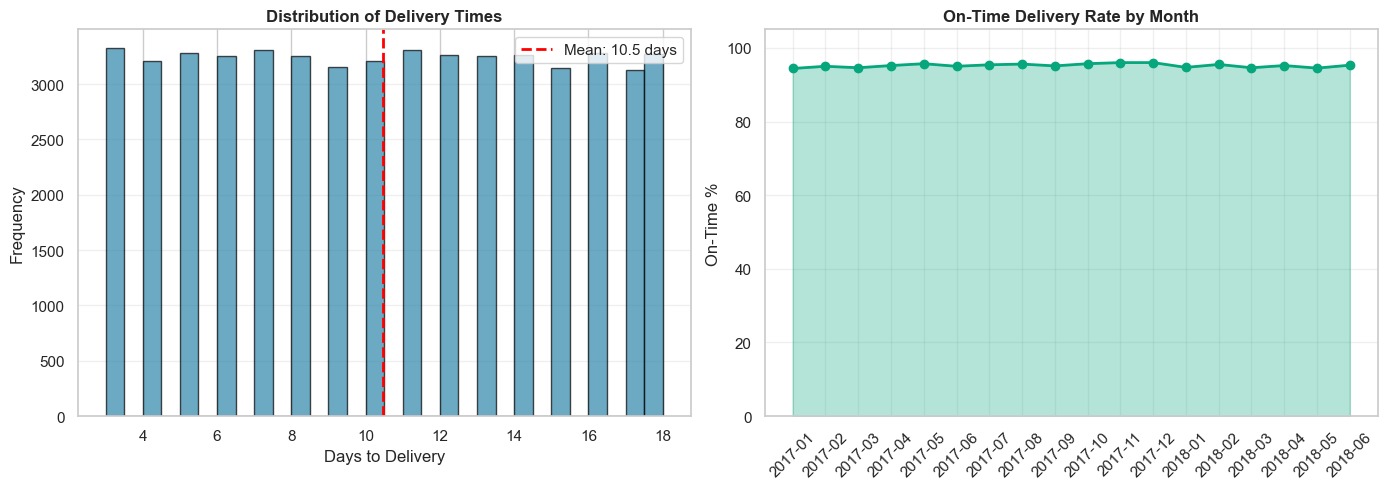


✅ Figure saved to reports/05_delivery_performance.png


In [ ]:
# Calculate delivery metrics
delivered_orders = df_orders_enriched[df_orders_enriched['order_status'] == 'delivered'].copy()
delivered_orders['days_to_deliver'] = (pd.to_datetime(delivered_orders['order_delivered_customer_date']) - 
                                         pd.to_datetime(delivered_orders['order_purchase_timestamp'])).dt.days
delivered_orders['is_on_time'] = (
    pd.to_datetime(delivered_orders['order_delivered_customer_date']) <= 
    pd.to_datetime(delivered_orders['order_estimated_delivery_date'])
)

on_time_pct = delivered_orders['is_on_time'].sum() / len(delivered_orders) * 100
avg_days = delivered_orders['days_to_deliver'].mean()

print(f"Delivery Metrics (Delivered Orders):")
print(f"  • On-time delivery rate: {on_time_pct:.1f}%")
print(f"  • Average days to deliver: {avg_days:.1f} days")
print(f"  • Median days to deliver: {delivered_orders['days_to_deliver'].median():.0f} days")
print(f"  • Min/Max: {delivered_orders['days_to_deliver'].min():.0f} / {delivered_orders['days_to_deliver'].max():.0f} days")

# Monthly delivery metrics
delivered_orders['order_month'] = delivered_orders['order_purchase_timestamp'].dt.strftime('%Y-%m')
monthly_delivery = delivered_orders.groupby('order_month').agg({
    'is_on_time': lambda x: (x.sum() / len(x) * 100).round(1),
    'days_to_deliver': 'mean'
}).round(2)
monthly_delivery.columns = ['on_time_pct', 'avg_days']
monthly_delivery = monthly_delivery.reset_index()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delivery days distribution
ax = axes[0]
ax.hist(delivered_orders['days_to_deliver'], bins=30, color='#2E86AB', alpha=0.7, edgecolor='black')
ax.axvline(avg_days, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_days:.1f} days')
ax.set_xlabel('Days to Delivery')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Delivery Times', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Monthly on-time trend
ax = axes[1]
ax.plot(monthly_delivery['order_month'], monthly_delivery['on_time_pct'], 
        marker='o', linewidth=2, markersize=6, color='#06A77D')
ax.fill_between(range(len(monthly_delivery)), monthly_delivery['on_time_pct'], alpha=0.3, color='#06A77D')
ax.set_ylabel('On-Time %')
ax.set_title('On-Time Delivery Rate by Month', fontsize=12, fontweight='bold')
ax.set_ylim([0, 105])
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / '05_delivery_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[SUCCESS] Figure saved to reports/05_delivery_performance.png")

## Summary

EDA complete. Key insights captured in visualizations. Next steps:
- Review revenue RCA notebook for detailed decomposition analysis
- Explore cohort retention patterns
- Launch Streamlit dashboard for interactive exploration

In [ ]:
print("[SUCCESS] EDA complete. Reports saved to reports/ folder.")
print()
print("Generated reports:")
print("  • 01_monthly_trends.png")
print("  • 02_geographic_analysis.png")
print("  • 03_category_analysis.png")
print("  • 04_review_analysis.png")
print("  • 05_delivery_performance.png")

✅ EDA complete. Reports saved to reports/ folder.

Generated reports:
  • 01_monthly_trends.png
  • 02_geographic_analysis.png
  • 03_category_analysis.png
  • 04_review_analysis.png
  • 05_delivery_performance.png
